# Paragliding Thermal Heatmap — Arbas Site

**Pipeline:**
1. Load real SRTM elevation data
2. Run simplified thermal/wind simulation (numpy-based Boussinesq)
3. Export vector fields as JSON for Three.js

**Note:** FEniCS/DOLFINx is not yet installed. Phase 2 uses a numpy-based finite-difference solver.

## Phase 1 — Terrain Data

In [17]:
import numpy as np
import rasterio
from rasterio.windows import from_bounds
from rasterio.merge import merge as rasterio_merge
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import json
import os
from datetime import datetime, timezone, timedelta
from pysolar.solar import get_altitude, get_azimuth

# Arbas site bounding box (updated)
BBOX = {
    'min_lon': 0.8384807238737125,
    'max_lon': 0.933902446260169,
    'min_lat': 42.96106090862103,
    'max_lat': 43.014963556361636,
    'center_lat': 42.99565929402203,
    'center_lon': 0.9054050088740738
}

# Waypoints
LANDING  = {'lat': 42.99216012970225,  'lon': 0.9039819278411977,  'name': 'Landing'}
TAKEOFF  = {'lat': 42.96939867981149,  'lon': 0.8859389033562173,  'name': 'Take-off'}

print('Imports OK')
print(f'Bbox: {BBOX["min_lat"]:.4f}–{BBOX["max_lat"]:.4f}N, {BBOX["min_lon"]:.4f}–{BBOX["max_lon"]:.4f}E')

Imports OK
Bbox: 42.9611–43.0150N, 0.8385–0.9339E


In [18]:
def fetch_srtm_tile(min_lon, min_lat, max_lon, max_lat, output_path):
    """Download SRTM1 tiles (30m) and merge+clip to bounding box."""
    import requests, gzip, shutil

    lat_tiles = range(int(np.floor(min_lat)), int(np.floor(max_lat)) + 1)
    lon_tiles = range(int(np.floor(min_lon)), int(np.floor(max_lon)) + 1)

    hgt_paths = []
    for lat in lat_tiles:
        for lon in lon_tiles:
            lat_str = f'N{lat:02d}' if lat >= 0 else f'S{abs(lat):02d}'
            lon_str = f'E{lon:03d}' if lon >= 0 else f'W{abs(lon):03d}'
            url = (f'https://s3.amazonaws.com/elevation-tiles-prod/skadi/'
                   f'{lat_str}/{lat_str}{lon_str}.hgt.gz')
            cache_gz  = f'/tmp/{lat_str}{lon_str}.hgt.gz'
            cache_hgt = f'/tmp/{lat_str}{lon_str}.hgt'

            if not os.path.exists(cache_hgt):
                print(f'Downloading {lat_str}{lon_str}...')
                r = requests.get(url, timeout=60)
                r.raise_for_status()
                with open(cache_gz, 'wb') as f:
                    f.write(r.content)
                with gzip.open(cache_gz, 'rb') as gz, open(cache_hgt, 'wb') as hgt:
                    shutil.copyfileobj(gz, hgt)
            else:
                print(f'Using cached {lat_str}{lon_str}')
            hgt_paths.append(cache_hgt)

    datasets = [rasterio.open(p) for p in hgt_paths]
    if len(datasets) == 1:
        merged, merged_transform = datasets[0].read(1), datasets[0].transform
        src_crs = datasets[0].crs
        src_dtype = datasets[0].dtypes[0]
        datasets[0].close()
    else:
        from rasterio.merge import merge as rasterio_merge
        merged_arr, merged_transform = rasterio_merge(datasets)
        merged = merged_arr[0]
        src_crs  = datasets[0].crs
        src_dtype = datasets[0].dtypes[0]
        for ds in datasets:
            ds.close()

    import io
    with rasterio.MemoryFile() as memfile:
        profile = {
            'driver': 'GTiff', 'dtype': src_dtype,
            'width': merged.shape[1], 'height': merged.shape[0],
            'count': 1, 'crs': src_crs, 'transform': merged_transform
        }
        with memfile.open(**profile) as mem:
            mem.write(merged, 1)
            from rasterio.windows import from_bounds
            window = from_bounds(min_lon, min_lat, max_lon, max_lat, mem.transform)
            elevation = mem.read(1, window=window).astype(np.float32)
            clip_transform = mem.window_transform(window)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    profile = {
        'driver': 'GTiff', 'dtype': 'float32',
        'width': elevation.shape[1], 'height': elevation.shape[0],
        'count': 1, 'crs': 'EPSG:4326', 'transform': clip_transform
    }
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(elevation, 1)

    return elevation, clip_transform


def fetch_highres_dem(min_lon, min_lat, max_lon, max_lat, output_path, zoom=14):
    """
    Download high-resolution DEM from AWS Terrain Tiles (Terrarium RGB encoding).

    At zoom=14, resolution is ~7 m/pixel at 43°N. For France the underlying
    source is IGN RGE Alti (LiDAR-derived), routed through the AWS tile CDN.

    Terrarium encoding: elevation = R×256 + G + B/256 − 32768  (metres)

    Tiles are in Web Mercator (EPSG:3857) and are reprojected to WGS84
    (EPSG:4326) before saving, so the output is compatible with the rest of
    the pipeline.
    """
    import math, requests
    from rasterio.transform import from_origin
    from rasterio.windows import from_bounds as win_from_bounds
    from rasterio.warp import reproject, Resampling, calculate_default_transform
    from rasterio.crs import CRS

    TILE_PX   = 256
    MERC_HALF = 20037508.342789244   # π × R_WGS84  (half-width of EPSG:3857)

    def lonlat_to_tile(lon, lat, z):
        n = 2 ** z
        x = int((lon + 180.0) / 360.0 * n)
        lat_r = math.radians(lat)
        y = int((1.0 - math.log(math.tan(lat_r) + 1.0 / math.cos(lat_r)) / math.pi) / 2.0 * n)
        return x, y

    def tile_merc_origin(tx, ty, z):
        """Web Mercator (x, y) of the top-left corner of tile (tx, ty)."""
        n   = 2 ** z
        x_m =  tx / n * 2 * MERC_HALF - MERC_HALF
        y_m = -ty / n * 2 * MERC_HALF + MERC_HALF
        return x_m, y_m

    # Tile range: y0 = northernmost tile row (smaller index), y1 = southernmost
    x0, y0 = lonlat_to_tile(min_lon, max_lat, zoom)   # NW corner
    x1, y1 = lonlat_to_tile(max_lon, min_lat, zoom)   # SE corner
    xs, ys  = list(range(x0, x1 + 1)), list(range(y0, y1 + 1))
    print(f'  Fetching {len(xs)} × {len(ys)} Terrarium tiles at zoom {zoom} …')

    # Stitch mosaic in EPSG:3857
    W = len(xs) * TILE_PX
    H = len(ys) * TILE_PX
    mosaic = np.zeros((H, W), dtype=np.float32)

    for ri, ty in enumerate(ys):
        for ci, tx in enumerate(xs):
            cache = f'/tmp/terrarium_{zoom}_{tx}_{ty}.png'
            if not os.path.exists(cache):
                url = f'https://s3.amazonaws.com/elevation-tiles-prod/terrarium/{zoom}/{tx}/{ty}.png'
                r = requests.get(url, timeout=30)
                r.raise_for_status()
                with open(cache, 'wb') as f:
                    f.write(r.content)
            with rasterio.open(cache) as tile_src:
                rgb = tile_src.read()   # (3, 256, 256) uint8
            elev = (rgb[0].astype(np.float32) * 256.0
                  + rgb[1].astype(np.float32)
                  + rgb[2].astype(np.float32) / 256.0) - 32768.0
            mosaic[ri*TILE_PX:(ri+1)*TILE_PX, ci*TILE_PX:(ci+1)*TILE_PX] = elev

    # Build EPSG:3857 Affine transform for the mosaic
    merc_px          = 2 * MERC_HALF / (2 ** zoom * TILE_PX)   # metres / pixel
    x_merc0, y_merc0 = tile_merc_origin(x0, y0, zoom)           # top-left corner
    src_transform    = from_origin(x_merc0, y_merc0, merc_px, merc_px)
    src_crs          = CRS.from_epsg(3857)
    dst_crs          = CRS.from_epsg(4326)

    # Reproject from EPSG:3857 → EPSG:4326
    merc_bounds = (
        x_merc0,                       # left
        y_merc0 - H * merc_px,         # bottom
        x_merc0 + W * merc_px,         # right
        y_merc0,                        # top
    )
    dst_transform, dst_w, dst_h = calculate_default_transform(
        src_crs, dst_crs, W, H,
        left=merc_bounds[0], bottom=merc_bounds[1],
        right=merc_bounds[2], top=merc_bounds[3],
    )
    reprojected = np.zeros((dst_h, dst_w), dtype=np.float32)
    reproject(
        source=mosaic, destination=reprojected,
        src_transform=src_transform, src_crs=src_crs,
        dst_transform=dst_transform,  dst_crs=dst_crs,
        resampling=Resampling.bilinear,
    )

    # Clip to requested bbox and save
    with rasterio.MemoryFile() as mem:
        profile = {'driver': 'GTiff', 'dtype': 'float32',
                   'width': dst_w, 'height': dst_h, 'count': 1,
                   'crs': dst_crs, 'transform': dst_transform}
        with mem.open(**profile) as ds:
            ds.write(reprojected, 1)
            win     = win_from_bounds(min_lon, min_lat, max_lon, max_lat, ds.transform)
            clipped = ds.read(1, window=win)
            clip_t  = ds.window_transform(win)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with rasterio.open(output_path, 'w', **{
        'driver': 'GTiff', 'dtype': 'float32',
        'width': clipped.shape[1], 'height': clipped.shape[0],
        'count': 1, 'crs': dst_crs, 'transform': clip_t,
    }) as dst:
        dst.write(clipped, 1)

    px_deg = abs(clip_t.a)
    px_m   = px_deg * 111320 * math.cos(math.radians((min_lat + max_lat) / 2))
    print(f'  Saved {clipped.shape[0]} × {clipped.shape[1]} px, ~{px_m:.1f} m/pixel → {output_path}')
    return clipped, clip_t


# ── Fetch both DEMs ───────────────────────────────────────────────────────────
TIF_PATH      = 'data/arbas_srtm.tif'        # 30 m — used for simulation
TIF_HIGHRES   = 'data/arbas_highres.tif'     # ~7 m — used for terrain mesh only

if not os.path.exists(TIF_PATH):
    elevation_raw, transform = fetch_srtm_tile(
        BBOX['min_lon'], BBOX['min_lat'], BBOX['max_lon'], BBOX['max_lat'], TIF_PATH
    )
    print(f'Fetched SRTM → {TIF_PATH}')
else:
    print(f'Using cached {TIF_PATH}')

if not os.path.exists(TIF_HIGHRES):
    print(f'Fetching high-res DEM (zoom=14, ~7 m) …')
    fetch_highres_dem(
        BBOX['min_lon'], BBOX['min_lat'], BBOX['max_lon'], BBOX['max_lat'], TIF_HIGHRES
    )
else:
    print(f'Using cached {TIF_HIGHRES}')

with rasterio.open(TIF_PATH) as src:
    elevation_raw = src.read(1).astype(np.float32)
    transform     = src.transform
    crs           = src.crs

with rasterio.open(TIF_HIGHRES) as src:
    elevation_highres = src.read(1).astype(np.float32)
    transform_highres = src.transform

print(f'\nSRTM   shape: {elevation_raw.shape}   range: {elevation_raw.min():.0f}–{elevation_raw.max():.0f} m')
print(f'HiRes  shape: {elevation_highres.shape}   range: {elevation_highres.min():.0f}–{elevation_highres.max():.0f} m')
print(f'CRS: {crs}')


Using cached data/arbas_srtm.tif
Using cached data/arbas_highres.tif

SRTM   shape: (194, 344)   range: 380–1592 m
HiRes  shape: (694, 1229)   range: 383–1565 m
CRS: EPSG:4326


In [19]:
def latlon_to_local(lat, lon, lat0, lon0):
    """Convert lat/lon to local East/North meters (equirectangular)."""
    R = 6371000
    x = (lon - lon0) * np.cos(np.radians(lat0)) * R * np.pi / 180
    y = -(lat - lat0) * R * np.pi / 180  # flip: north is +Y
    return float(x), float(y)


def extract_3d_terrain(tif_path, sampling_step=1):
    """Convert GeoTIFF to structured X, Y, Z grids in meters (local frame)."""
    with rasterio.open(tif_path) as src:
        elevation = src.read(1, masked=True).astype(np.float32)
        t = src.transform

        rows, cols = np.mgrid[0:elevation.shape[0]:sampling_step,
                               0:elevation.shape[1]:sampling_step]
        lons = t.c + cols * t.a
        lats = t.f + rows * t.e
        z = elevation[::sampling_step, ::sampling_step]

        lat0 = float(lats.mean())
        lon0 = float(lons.mean())
        R = 6371000
        X = (lons - lon0) * np.cos(np.radians(lat0)) * R * np.pi / 180
        Y = -(lats - lat0) * R * np.pi / 180
        Z = np.array(z)

    return X, Y, Z, lons, lats, lat0, lon0


X, Y, Z, lons, lats, LAT0, LON0 = extract_3d_terrain(TIF_PATH)
print(f'SRTM 3D terrain grid: {X.shape}')
print(f'Physical extent: X={X.min():.0f}–{X.max():.0f}m, Y={Y.min():.0f}–{Y.max():.0f}m')
print(f'Projection origin: lat={LAT0:.5f}, lon={LON0:.5f}')

# Compute waypoint local coords + terrain elevation under each
def elevation_at(lat, lon, elev_grid, lats_grid, lons_grid):
    iy = int(np.argmin(np.abs(lats_grid[:, 0] - lat)))
    ix = int(np.argmin(np.abs(lons_grid[0, :] - lon)))
    return float(elev_grid[iy, ix])

for wp in (LANDING, TAKEOFF):
    wx, wy = latlon_to_local(wp['lat'], wp['lon'], LAT0, LON0)
    wz = elevation_at(wp['lat'], wp['lon'], Z, lats, lons)
    wp['x'], wp['y'], wp['z'] = wx, wy, wz
    print(f"{wp['name']}: x={wx:.0f}m, y={wy:.0f}m, z={wz:.0f}m")

# ── High-resolution mesh grid (AWS Terrarium ~7 m) ───────────────────────────
# Used only for the visual terrain mesh; simulation stays on the 30 m SRTM grid.
X_mesh, Y_mesh, Z_mesh, lons_mesh, lats_mesh, _, _ = extract_3d_terrain(TIF_HIGHRES)

MESH_NX = Z_mesh.shape[1]
MESH_NY = Z_mesh.shape[0]
mesh_dx = float(X_mesh[0, 1] - X_mesh[0, 0])  if MESH_NX > 1 else float(dx)
mesh_dy = float(abs(Y_mesh[1, 0] - Y_mesh[0, 0])) if MESH_NY > 1 else float(abs(dy))

print(f'\nHigh-res mesh: {MESH_NX} × {MESH_NY} cells, '
      f'dx={mesh_dx:.1f} m, dy={mesh_dy:.1f} m')
print(f'  Z range: {Z_mesh.min():.0f} – {Z_mesh.max():.0f} m')


SRTM 3D terrain grid: (194, 344)
Physical extent: X=-3875–3875m, Y=-2981–2981m
Projection origin: lat=42.98816, lon=0.88612
Landing: x=1453m, y=-445m, z=420m
Take-off: x=-15m, y=2086m, z=1108m

High-res mesh: 1229 × 694 cells, dx=6.3 m, dy=8.6 m
  Z range: 383 – 1565 m


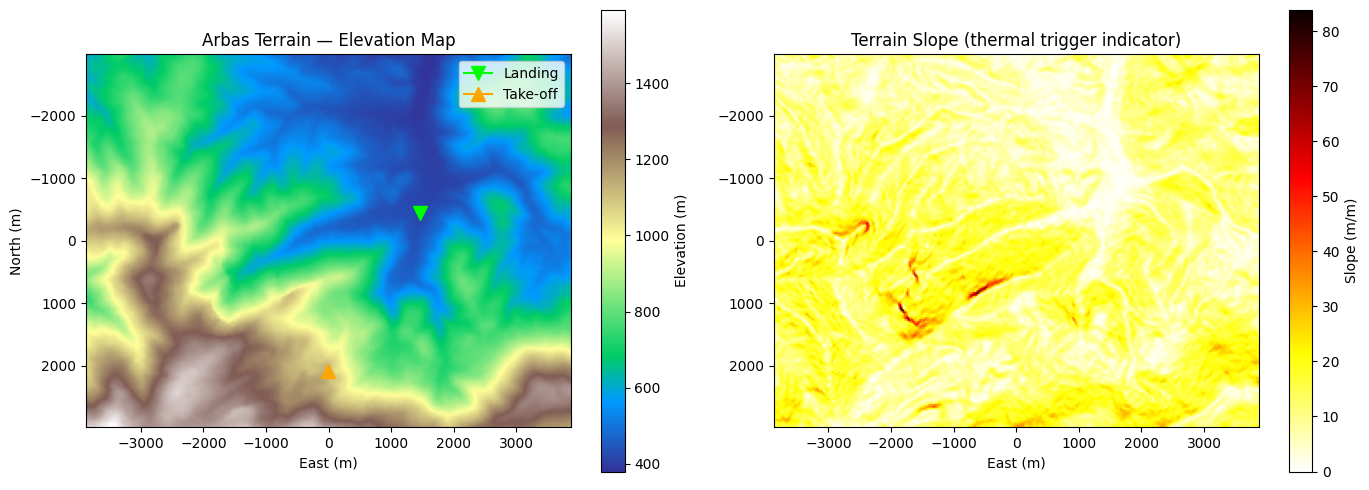

Saved data/terrain_visualization.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# With origin='upper', row 0 is at the top of the image (northernmost).
# extent=[left, right, bottom, top] — swap Y so top=Y.min (north), bottom=Y.max (south).
extent = [X.min(), X.max(), Y.max(), Y.min()]

im = axes[0].imshow(Z, cmap='terrain', origin='upper', extent=extent)
plt.colorbar(im, ax=axes[0], label='Elevation (m)')
axes[0].set_title('Arbas Terrain — Elevation Map')
axes[0].set_xlabel('East (m)'); axes[0].set_ylabel('North (m)')

for wp, color, marker in [(LANDING, 'lime', 'v'), (TAKEOFF, 'orange', '^')]:
    axes[0].plot(wp['x'], wp['y'], marker=marker, color=color, ms=10, label=wp['name'])
axes[0].legend()

dzdx = np.gradient(Z, axis=1)
dzdy = np.gradient(Z, axis=0)
slope = np.sqrt(dzdx**2 + dzdy**2)
im2 = axes[1].imshow(slope, cmap='hot_r', origin='upper', extent=extent)
plt.colorbar(im2, ax=axes[1], label='Slope (m/m)')
axes[1].set_title('Terrain Slope (thermal trigger indicator)')
axes[1].set_xlabel('East (m)')

plt.tight_layout()
plt.savefig('data/terrain_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved data/terrain_visualization.png')

In [21]:

# ── Land-cover classes: code → (label, hex colour, thermal factor) ────────────
# Thermal factor: relative ground temperature anomaly vs grassland (=1.0).
# Encodes both thermal inertia (low = heats fast) and albedo (high = reflects more).
LANDCOVER = {
    10:  ('Tree cover',          '#1a7a1a', 0.45),  # dense canopy, high inertia
    20:  ('Shrubland',           '#8db34a', 0.70),
    30:  ('Grassland',           '#c8d980', 1.00),  # reference
    40:  ('Cropland',            '#e8c84a', 0.85),
    50:  ('Built-up',            '#d03020', 1.30),  # concrete / low inertia
    60:  ('Bare / sparse veg',   '#a08060', 1.80),  # rock & scree, very low inertia
    70:  ('Snow and ice',        '#f0f0ff', 0.08),  # very high albedo
    80:  ('Permanent water',     '#1a50d0', 0.03),  # highest thermal inertia
    90:  ('Herbaceous wetland',  '#50a0a0', 0.35),
    95:  ('Mangrove',            '#008080', 0.50),
    100: ('Moss and lichen',     '#90c090', 0.60),
}

def fetch_landcover(min_lon, min_lat, max_lon, max_lat, output_path):
    """Clip ESA WorldCover 2021 (10 m COG) to the bounding box via HTTP range requests."""
    url = ('https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/'
           'ESA_WorldCover_10m_2021_v200_N42E000_Map.tif')
    with rasterio.open(url) as src:
        window = from_bounds(min_lon, min_lat, max_lon, max_lat, src.transform)
        data   = src.read(1, window=window)
        transform = src.window_transform(window)
        profile = {
            'driver': 'GTiff', 'dtype': data.dtype,
            'width': data.shape[1], 'height': data.shape[0],
            'count': 1, 'crs': src.crs, 'transform': transform,
        }
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(data, 1)
    return data, transform

LC_PATH = 'data/arbas_landcover.tif'

if not os.path.exists(LC_PATH):
    print('Fetching ESA WorldCover 2021 (COG range request)…')
    lc_raw, lc_transform = fetch_landcover(
        BBOX['min_lon'], BBOX['min_lat'], BBOX['max_lon'], BBOX['max_lat'], LC_PATH)
    print(f'Saved {LC_PATH}')
else:
    print(f'Using cached {LC_PATH}')
    with rasterio.open(LC_PATH) as src:
        lc_raw, lc_transform = src.read(1), src.transform

classes_present = np.unique(lc_raw).tolist()
print(f'Shape: {lc_raw.shape}  Resolution: ~{abs(lc_transform.a)*111320:.0f} m/pixel')
print('Classes found:')
for c in classes_present:
    label, _, factor = LANDCOVER.get(c, (f'Unknown ({c})', '#888', 1.0))
    count = (lc_raw == c).sum()
    print(f'  {c:3d}  {label:<25s}  thermal factor={factor:.2f}  ({count/lc_raw.size*100:.1f}%)')


Using cached data/arbas_landcover.tif
Shape: (647, 1145)  Resolution: ~9 m/pixel
Classes found:
   10  Tree cover                 thermal factor=0.45  (88.5%)
   20  Shrubland                  thermal factor=0.70  (0.0%)
   30  Grassland                  thermal factor=1.00  (11.1%)
   40  Cropland                   thermal factor=0.85  (0.1%)
   50  Built-up                   thermal factor=1.30  (0.3%)


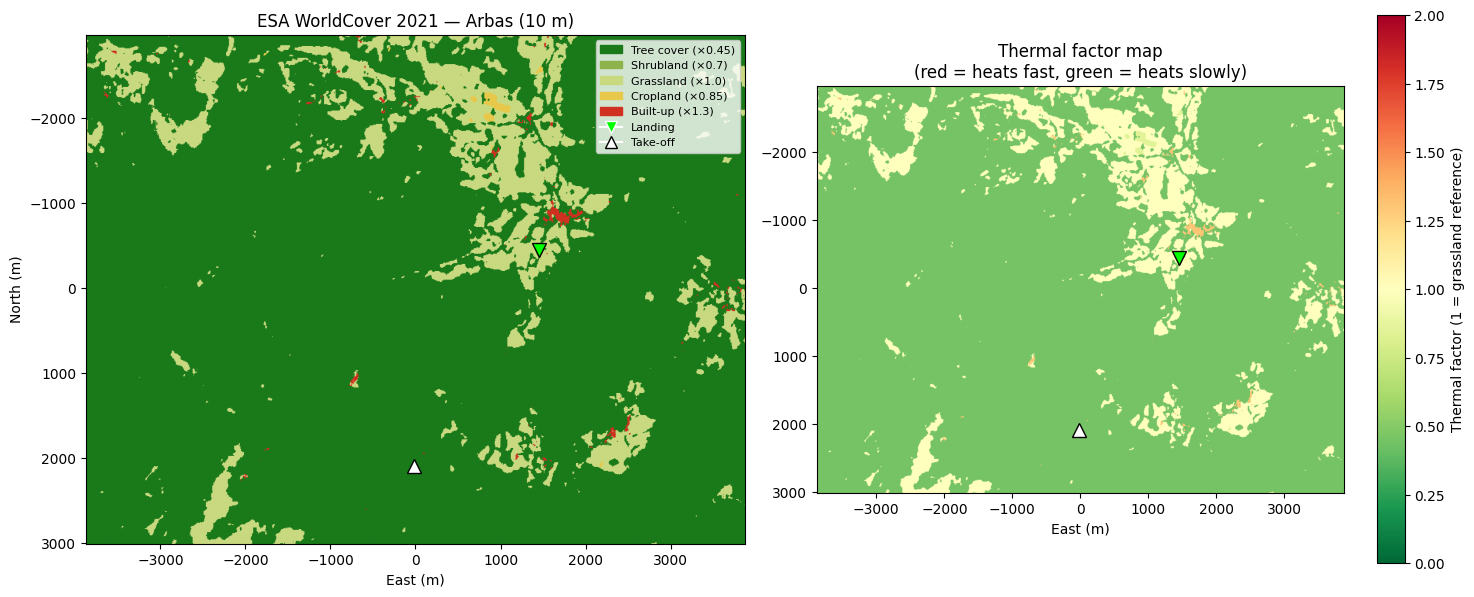

Saved data/landcover_visualization.png


In [22]:

# ── Visualise land cover ───────────────────────────────────────────────────────
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

# Build a colormap aligned to the class codes present
codes   = sorted(LANDCOVER.keys())
labels  = [LANDCOVER[c][0]   for c in codes]
colors  = [LANDCOVER[c][1]   for c in codes]
factors = [LANDCOVER[c][2]   for c in codes]

cmap_lc = ListedColormap(colors)
bounds  = [c - 0.5 for c in codes] + [codes[-1] + 0.5]
norm_lc = BoundaryNorm(bounds, cmap_lc.N)

# Local extent for axes (same convention as terrain plots: Y flipped)
lc_rows, lc_cols = np.mgrid[0:lc_raw.shape[0], 0:lc_raw.shape[1]]
lc_lons = lc_transform.c + lc_cols * lc_transform.a
lc_lats = lc_transform.f + lc_rows * lc_transform.e
lc_X = (lc_lons - LON0) * np.cos(np.radians(LAT0)) * 6371000 * np.pi / 180
lc_Y = -(lc_lats - LAT0) * 6371000 * np.pi / 180
lc_extent = [lc_X.min(), lc_X.max(), lc_Y.max(), lc_Y.min()]

# Thermal factor raster (for visual inspection)
factor_grid = np.vectorize(lambda c: LANDCOVER.get(c, ('', '', 1.0))[2])(lc_raw)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: categorical land cover ─────────────────────────────────────────────
im_lc = axes[0].imshow(lc_raw, cmap=cmap_lc, norm=norm_lc,
                        origin='upper', extent=lc_extent)
for wp, color, marker in [(LANDING, 'lime', 'v'), (TAKEOFF, 'white', '^')]:
    axes[0].plot(wp['x'], wp['y'], marker=marker, color=color,
                 ms=10, markeredgecolor='k', label=wp['name'])
legend_patches = [Patch(color=LANDCOVER[c][1], label=f"{LANDCOVER[c][0]} (×{LANDCOVER[c][2]})")
                  for c in classes_present]
legend_patches += [plt.Line2D([0],[0], marker='v', color='w', markerfacecolor='lime',
                               markersize=9, label='Landing'),
                   plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='white',
                               markeredgecolor='k', markersize=9, label='Take-off')]
axes[0].legend(handles=legend_patches, fontsize=8, loc='upper right')
axes[0].set_title('ESA WorldCover 2021 — Arbas (10 m)')
axes[0].set_xlabel('East (m)'); axes[0].set_ylabel('North (m)')

# ── Right: thermal factor ─────────────────────────────────────────────────────
im_tf = axes[1].imshow(factor_grid, cmap='RdYlGn_r', vmin=0, vmax=2,
                        origin='upper', extent=lc_extent)
plt.colorbar(im_tf, ax=axes[1], label='Thermal factor (1 = grassland reference)')
for wp, color, marker in [(LANDING, 'lime', 'v'), (TAKEOFF, 'white', '^')]:
    axes[1].plot(wp['x'], wp['y'], marker=marker, color=color,
                 ms=10, markeredgecolor='k')
axes[1].set_title('Thermal factor map\n(red = heats fast, green = heats slowly)')
axes[1].set_xlabel('East (m)')

plt.tight_layout()
plt.savefig('data/landcover_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved data/landcover_visualization.png')


## Phase 2 — Thermal Simulation (Numpy-based Boussinesq)

In [23]:
from scipy.ndimage import gaussian_filter

# Physical constants
g    = 9.81
beta = 0.0034
T0   = 293.15

# Atmospheric lapse rates (K/m)
DALR = 0.0098   # Dry Adiabatic Lapse Rate — fixed by thermodynamics
ELR  = 0.0065   # Environmental Lapse Rate  — standard ICAO atmosphere
                # Increase → less stable → higher thermal tops (good flying)
                # Decrease → more stable  → lower  thermal tops (poor flying)

# Thermal inertia time constant (hours)
# Ground temperature relaxes toward the current-sun equilibrium with this lag.
# Smaller → fast response (bare rock/gravel); Larger → slow (dense forest/water).
# ~1 h for bare rock, ~1.5 h mixed terrain, ~3 h for forest/water.
TAU_HOURS = 1.5

# Match simulation grid exactly to terrain resolution — no downsampling
SIM_NY, SIM_NX = Z.shape          # 194 × 344
SIM_NZ  = 32
DOMAIN_H = 2000

Z_sim = Z.copy()                   # no zoom needed
X_sim = X[0, :]                    # (SIM_NX,)
Y_sim = Y[:, 0]                    # (SIM_NY,)
dx = float(X_sim[1] - X_sim[0])
dy = float(Y_sim[1] - Y_sim[0])
Z_min = float(Z_sim.min())
Z_max = float(Z_sim.max())
dz = DOMAIN_H / SIM_NZ

print(f'Simulation grid: {SIM_NX} × {SIM_NY} × {SIM_NZ}')
print(f'Grid spacing: dx={dx:.1f} m, dy={dy:.1f} m, dz={dz:.1f} m')
print(f'Terrain elevation: {Z_min:.0f} – {Z_max:.0f} m')
print(f'Lapse rates: DALR={DALR*1000:.1f} K/km, ELR={ELR*1000:.1f} K/km')
print(f'  → thermal tops: dT=5K → {5/(DALR-ELR):.0f} m AGL, '
      f'dT=10K → {10/(DALR-ELR):.0f} m AGL')
print(f'Thermal inertia τ = {TAU_HOURS} h')


Simulation grid: 344 × 194 × 32
Grid spacing: dx=22.6 m, dy=30.9 m, dz=62.5 m
Terrain elevation: 380 – 1592 m
Lapse rates: DALR=9.8 K/km, ELR=6.5 K/km
  → thermal tops: dT=5K → 1515 m AGL, dT=10K → 3030 m AGL
Thermal inertia τ = 1.5 h


In [24]:
from scipy.ndimage import zoom as ndimage_zoom

# Resample from 10 m WorldCover (647 × 1145) → terrain resolution (194 × 344)
# order=0 = nearest-neighbour: preserves integer class codes
scale_lc_y = SIM_NY / lc_raw.shape[0]
scale_lc_x = SIM_NX / lc_raw.shape[1]
lc_sim = ndimage_zoom(lc_raw, (scale_lc_y, scale_lc_x), order=0)

thermal_factor_sim = np.vectorize(
    lambda c: LANDCOVER.get(int(c), ('', '', 1.0))[2]
)(lc_sim).astype(np.float32)

# Blur class boundaries so the albedo overlay shows smooth transitions
# sigma=4 px ≈ 90 m at the terrain grid spacing
thermal_factor_sim = gaussian_filter(thermal_factor_sim, sigma=4)

print(f'Landcover sim grid: {lc_sim.shape}')
print(f'Thermal factor range after blur: {thermal_factor_sim.min():.2f} – {thermal_factor_sim.max():.2f}')
print('Class distribution on sim grid:')
for c in np.unique(lc_sim):
    label = LANDCOVER.get(int(c), (f'Unknown ({c})', '', 1.0))[0]
    pct = (lc_sim == c).sum() / lc_sim.size * 100
    print(f'  {int(c):3d}  {label:<25s}  {pct:.1f} %')


Landcover sim grid: (194, 344)
Thermal factor range after blur: 0.45 – 0.96
Class distribution on sim grid:
   10  Tree cover                 88.5 %
   30  Grassland                  11.1 %
   40  Cropland                   0.1 %
   50  Built-up                   0.3 %


In [25]:
def compute_solar_heating(Z_grid, sun_azimuth_deg, sun_elevation_deg,
                           thermal_factor=None, max_heat=15.0, shadow_mask=None,
                           diffuse_fraction=0.3):
    """
    Ground temperature anomaly dT per cell.

    Irradiance model:
      I_total = I_direct + I_diffuse

      I_direct  = cos(incidence) × T_atm          — blocked by terrain shadows
      I_diffuse = diffuse_fraction × (1−T_atm) × SVF   — NOT blocked by shadows
                  ↑ more scattering at low sun       ↑ sky view factor

      Sky view factor SVF = (1 + cos(slope)) / 2
        → flat ground = 1.0, vertical wall = 0.5

      Atmospheric transmittance via Kasten-Young air mass + Bird model:
        AM     = 1 / (sin(el) + 0.50572·(el_deg + 6.07995)^−1.6364)
        T_atm  = 0.7 ^ (AM ^ 0.678)

    Parameters
    ----------
    diffuse_fraction : float
        Fraction of scattered (lost) beam that reaches ground as diffuse sky light.
        0.3 is a good clear-sky estimate; increase toward 0.5 for hazy conditions.

    shadow_mask : ndarray, optional
        1.0 = in shadow (direct beam blocked), 0.0 = lit.
        Diffuse component is always added regardless of shadow.
    """
    dzdx = np.gradient(Z_grid, axis=1)   # ∂Z/∂East
    dzdy = np.gradient(Z_grid, axis=0)   # ∂Z/∂South

    # Outward surface normal in (East, North, Up)
    nx_ = -dzdx
    ny_ =  dzdy
    nz_ = np.ones_like(Z_grid)
    norm = np.sqrt(nx_**2 + ny_**2 + nz_**2)
    nx_, ny_, nz_ = nx_/norm, ny_/norm, nz_/norm

    # Sun direction (East, North, Up)
    az = np.radians(sun_azimuth_deg)
    el = np.radians(sun_elevation_deg)
    sx = np.sin(az) * np.cos(el)
    sy = np.cos(az) * np.cos(el)
    sz = np.sin(el)

    # ── Atmospheric transmittance (Kasten-Young + Bird) ──────────────────────
    AM    = 1.0 / (np.sin(el) + 0.50572 * (sun_elevation_deg + 6.07995) ** -1.6364)
    T_atm = 0.7 ** (AM ** 0.678)
    # ─────────────────────────────────────────────────────────────────────────

    # ── Direct beam ──────────────────────────────────────────────────────────
    direct = np.clip(nx_*sx + ny_*sy + nz_*sz, 0, 1)
    direct = gaussian_filter(direct, sigma=1.5)
    direct *= T_atm
    if shadow_mask is not None:
        direct *= (1.0 - shadow_mask)   # terrain shadow blocks direct beam only
    # ─────────────────────────────────────────────────────────────────────────

    # ── Diffuse sky radiation ─────────────────────────────────────────────────
    # Sky view factor: fraction of the sky hemisphere visible from this cell.
    # Isotropic approximation: SVF = (1 + cos(terrain_slope)) / 2
    # Flat ground → 1.0; steep south-facing cliff → ~0.5
    slope = np.arctan(np.sqrt(dzdx**2 + dzdy**2))   # terrain slope angle (radians)
    svf   = (1.0 + np.cos(slope)) / 2.0

    # Diffuse irradiance scales with how much beam was scattered (1 − T_atm):
    # more atmospheric scattering at low sun → more diffuse light reaching ground.
    diffuse = diffuse_fraction * (1.0 - T_atm) * svf
    # Note: diffuse is NOT multiplied by shadow_mask — shadowed cells still
    # receive sky-dome radiation from the visible portion of the hemisphere.
    # ─────────────────────────────────────────────────────────────────────────

    insolation = direct + diffuse

    dT = max_heat * insolation

    if thermal_factor is not None:
        dT = dT * thermal_factor

    return dT


dT_ground = compute_solar_heating(Z_sim, 180, 65, thermal_factor=thermal_factor_sim)
print(f'dT range (midday, with land-cover): {dT_ground.min():.2f} – {dT_ground.max():.2f} K')

# Illustrate the direct / diffuse split at key sun elevations
print('\nDirect vs diffuse split by sun elevation (flat horizontal surface, no shadow):')
print(f'  {"El":>4s}  {"AM":>5s}  {"T_atm":>6s}  {"Direct":>8s}  {"Diffuse":>8s}  {"Total":>7s}')
for el_deg in [10, 15, 20, 30, 45, 60, 68]:
    el_r  = np.radians(el_deg)
    AM    = 1.0 / (np.sin(el_r) + 0.50572 * (el_deg + 6.07995) ** -1.6364)
    T     = 0.7 ** (AM ** 0.678)
    d_dir = T * np.sin(el_r)          # direct on horizontal (cos(zenith) = sin(el))
    d_dif = 0.3 * (1 - T) * 1.0      # diffuse, SVF=1 (flat)
    print(f'  {el_deg:4d}°  {AM:5.2f}  {T:6.3f}  {d_dir:8.3f}  {d_dif:8.3f}  {d_dir+d_dif:7.3f}')


dT range (midday, with land-cover): 0.33 – 7.63 K

Direct vs diffuse split by sun elevation (flat horizontal surface, no shadow):
    El     AM   T_atm    Direct   Diffuse    Total
    10°   5.59   0.318     0.055     0.205    0.260
    15°   3.81   0.413     0.107     0.176    0.283
    20°   2.90   0.480     0.164     0.156    0.320
    30°   1.99   0.566     0.283     0.130    0.413
    45°   1.41   0.637     0.451     0.109    0.559
    60°   1.15   0.675     0.585     0.098    0.682
    68°   1.08   0.687     0.637     0.094    0.731


In [26]:
def compute_shadow_mask(Z, dx, dy, sun_az_deg, sun_el_deg):
    """
    DEM horizon shadow by vectorised ray-casting.

    For each grid cell, march step-by-step toward the sun along the DEM.
    If any sample point is higher than the sun ray originating from that
    cell, the cell is shadowed (no direct insolation).

    Grid convention:
      Z[j, i]  — j=0 is northernmost row, j increases southward
                  i=0 is westernmost  col, i increases eastward
      dx > 0   — physical width  of one i-step (metres, East)
      dy > 0   — physical height of one j-step (metres, South)

    Returns
      float32 mask (ny, nx): 0.0 = lit, 1.0 = in shadow.
    """
    ny, nx = Z.shape
    az     = np.radians(sun_az_deg)
    el     = np.radians(sun_el_deg)
    tan_el = np.tan(el)

    # Unit step in grid coords toward the sun.
    # i increases East  →  di =  sin(az)
    # j increases South →  dj = -cos(az)  (north = decrease j)
    di =  np.sin(az)
    dj = -np.cos(az)

    # Normalise so the dominant axis advances exactly 1 pixel per step.
    max_abs = max(abs(di), abs(dj))
    if max_abs < 1e-9:          # sun at zenith — no horizontal shadow
        return np.zeros((ny, nx), dtype=np.float32)
    di /= max_abs
    dj /= max_abs

    # Physical ground distance per normalised step.
    step_m = np.sqrt((di * dx) ** 2 + (dj * dy) ** 2)

    # Starting grid indices for every cell (broadcast 2-D arrays).
    j0 = np.arange(ny, dtype=np.float64)[:, None] * np.ones((1, nx))
    i0 = np.ones((ny, 1)) * np.arange(nx, dtype=np.float64)[None, :]
    z0 = Z.astype(np.float64)

    shadow = np.zeros((ny, nx), dtype=bool)
    active = np.ones((ny, nx),  dtype=bool)   # cells not yet determined

    max_steps = int(np.ceil(max(nx / max(abs(di), 1e-9),
                                ny / max(abs(dj), 1e-9)))) + 1

    for step in range(1, max_steps + 1):
        ri = np.round(i0 + step * di).astype(np.int32)
        rj = np.round(j0 + step * dj).astype(np.int32)

        in_bounds = (ri >= 0) & (ri < nx) & (rj >= 0) & (rj < ny)
        active   &= in_bounds           # cells that left the grid → lit (no blocker found)
        if not active.any():
            break

        ri_c = np.clip(ri, 0, nx - 1)
        rj_c = np.clip(rj, 0, ny - 1)

        dist        = step * step_m
        sun_ray_z   = z0 + dist * tan_el   # height of sun ray at this distance
        z_terrain   = Z[rj_c, ri_c]

        newly_blocked = active & (z_terrain > sun_ray_z)
        shadow       |= newly_blocked
        active       &= ~newly_blocked      # stop marching once blocked

    return shadow.astype(np.float32)


# Quick sanity check on midday scenario (sun from south at 65°)
_sm = compute_shadow_mask(Z_sim, dx, dy, 180, 65)
print(f'Shadow mask (midday): {int(_sm.sum()):,} shadowed cells '
      f'({_sm.mean()*100:.1f}% of {_sm.size:,})')

Shadow mask (midday): 10 shadowed cells (0.0% of 66,736)


In [27]:
def generate_sun_scenarios(lat, lon,
                            date_str='2024-07-15',
                            tz_offset_hours=2,
                            interval_minutes=30,
                            min_elevation_deg=0.0):
    """
    Generate sun positions (azimuth, elevation) at regular intervals
    throughout the day using real astronomical calculations (pysolar).

    Parameters
    ----------
    lat, lon           : site coordinates (decimal degrees)
    date_str           : ISO date string, e.g. '2024-07-15'
    tz_offset_hours    : UTC offset in hours (e.g. 2 for CEST)
    interval_minutes   : time step between scenarios (30 recommended)
    min_elevation_deg  : minimum sun elevation to include (filters twilight)

    Returns
    -------
    list of dicts with keys:
      name, local_time, utc_time, sun_azimuth, sun_elevation
    """
    year, month, day = [int(x) for x in date_str.split('-')]
    tz = timezone(timedelta(hours=tz_offset_hours))
    utc = timezone.utc

    scenarios = []
    # Scan full day at the requested interval
    minutes_in_day = 24 * 60
    for m in range(0, minutes_in_day, interval_minutes):
        hour_utc, min_utc = divmod(m, 60)
        dt_utc = datetime(year, month, day, hour_utc, min_utc, tzinfo=utc)
        el = get_altitude(lat, lon, dt_utc)
        if el < min_elevation_deg:
            continue
        az = get_azimuth(lat, lon, dt_utc)   # degrees, North = 0, clockwise

        dt_local = dt_utc.astimezone(tz)
        local_str = dt_local.strftime('%H:%M')
        utc_str   = dt_utc.strftime('%H:%M')

        scenarios.append({
            'name':          local_str,
            'local_time':    local_str,
            'utc_time':      utc_str,
            'sun_azimuth':   round(az, 2),
            'sun_elevation': round(el, 2),
        })

    return scenarios


# Preview the generated scenarios
SIMULATION_DATE = '2024-07-15'
TZ_OFFSET       = 2          # CEST (UTC+2)
INTERVAL_MIN    = 60         # minutes between steps

preview = generate_sun_scenarios(
    BBOX['center_lat'], BBOX['center_lon'],
    date_str=SIMULATION_DATE,
    tz_offset_hours=TZ_OFFSET,
    interval_minutes=INTERVAL_MIN,
)
print(f'{len(preview)} scenarios on {SIMULATION_DATE} (CEST, el > 10°):')
print(f'  {"Local":6s}  {"UTC":5s}  {"Az":>6s}  {"El":>5s}')
for s in preview:
    print(f'  {s["local_time"]}  {s["utc_time"]}  {s["sun_azimuth"]:6.1f}°  {s["sun_elevation"]:5.1f}°')

15 scenarios on 2024-07-15 (CEST, el > 10°):
  Local   UTC        Az     El
  07:00  05:00    64.0°    4.0°
  08:00  06:00    73.6°   14.1°
  09:00  07:00    83.1°   24.8°
  10:00  08:00    93.1°   35.7°
  11:00  09:00   104.9°   46.5°
  12:00  10:00   120.5°   56.6°
  13:00  11:00   144.0°   64.8°
  14:00  12:00   178.5°   68.4°
  15:00  13:00   213.6°   65.3°
  16:00  14:00   237.9°   57.4°
  17:00  15:00   254.0°   47.3°
  18:00  16:00   265.9°   36.5°
  19:00  17:00   276.1°   25.6°
  20:00  18:00   285.6°   14.9°
  21:00  19:00   295.2°    4.7°


In [28]:
def compute_thermal_field(Z_grid, dT_ground):
    """
    Vertical velocity field driven by surface temperature anomaly dT.

    Vertical profile
    ----------------
    Real thermals accelerate through the lower boundary layer and peak in the
    mid-BL before decelerating to zero at the thermal ceiling.  The profile
    used here is:

        w(z) ∝ (z/h_top) × (1 − z/h_top)^1.5

    This family f(z) = z^α · (1−z)^β peaks at z* = α/(α+β).
    With α=1, β=1.5  →  z* = 1/2.5 = 0.40 = 40 % of h_top.

    The normalisation constant 5.38 = 1 / (0.4 × 0.6^1.5) sets the peak to 1,
    so the overall scale is set by g·β·dT_ground.

    Previous formula  w ∝ dT_at_z × z/(z+100)  peaked at only ~20 % of h_top
    because the buoyancy factor dT_at_z is largest near the ground and the
    ramp z/(z+100) already saturates within the first 300 m.

    Parameters
    ----------
    dT_ground : (ny, nx) surface temperature anomaly (K)
    Returns
    -------
    u, v, w : (nz, ny, nx) float  (u=v=0 — only vertical component computed)
    """
    NX, NY, NZ = SIM_NX, SIM_NY, SIM_NZ
    u = np.zeros((NZ, NY, NX))
    v = np.zeros((NZ, NY, NX))
    w = np.zeros((NZ, NY, NX))

    z_levels  = Z_min + (np.arange(NZ) + 0.5) * dz
    d_lapse   = DALR - ELR          # K/m (positive → thermals exist)

    # Thermal ceiling AGL per cell (avoid divide-by-zero)
    h_top = np.where(dT_ground > 0, dT_ground / d_lapse, 0.0)

    # Normalisation: 1 / max(z*(1-z)^1.5) = 1 / (0.4 * 0.6^1.5) ≈ 5.38
    NORM = 1.0 / (0.4 * 0.6 ** 1.5)   # ≈ 5.38

    for k, z_k in enumerate(z_levels):
        z_above = np.maximum(z_k - Z_grid, 0.0)
        above   = z_k > Z_grid

        # Fractional height within thermal (0 at ground, 1 at ceiling)
        zfrac = np.where(h_top > 0, np.clip(z_above / h_top, 0, 1), 0.0)

        # Bell profile peaking at 40 % of h_top, zero at ground and ceiling
        w_raw = g * beta * dT_ground * NORM * zfrac * (1 - zfrac) ** 1.5
        w[k]  = np.where(above & (h_top > 0), np.clip(w_raw, 0, 8.0), 0.0)

        # Weak compensating sink above the thermal top (mass conservation)
        above_top = above & (zfrac >= 1.0)
        if above_top.sum() > 0 and w[k].mean() > 0:
            w[k][above_top] -= w[k].mean()

    w = gaussian_filter(w, sigma=[0.5, 1.5, 1.5])
    return u, v, w


u, v, w = compute_thermal_field(Z_sim, dT_ground)
print(f'Thermal field: w range {w.min():.2f} – {w.max():.2f} m/s')

# Show profile shape at the strongest cell to verify peak location
best = np.unravel_index(dT_ground.argmax(), dT_ground.shape)
dT_b = float(dT_ground[best])
h_b  = dT_b / (DALR - ELR)
print(f'\nProfile at strongest cell (dT={dT_b:.1f} K, h_top={h_b:.0f} m AGL):')
print(f'  {"z_frac":>7s}  {"z_AGL (m)":>10s}  {"w (m/s)":>8s}')
for zf in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    z_agl = zf * h_b
    wr = g * beta * dT_b * (1.0 / (0.4 * 0.6**1.5)) * zf * (1 - zf)**1.5
    print(f'  {zf:7.1f}  {z_agl:10.0f}  {wr:8.3f}')
print(f'  (peak expected at z_frac = 0.40)')

d_lapse = DALR - ELR
h_top_field = np.where(dT_ground > 0, dT_ground / d_lapse, 0.0)
print(f'\nThermal top AGL: 0 – {h_top_field.max():.0f} m  '
      f'(mean over lit cells: {h_top_field[h_top_field>0].mean():.0f} m)')


Thermal field: w range -0.02 – 0.24 m/s

Profile at strongest cell (dT=7.6 K, h_top=2314 m AGL):
   z_frac   z_AGL (m)   w (m/s)
      0.1         231     0.117
      0.2         463     0.196
      0.3         694     0.241
      0.4         925     0.255
      0.5        1157     0.242
      0.6        1388     0.208
      0.7        1620     0.158
      0.8        1851     0.098
      0.9        2082     0.039
  (peak expected at z_frac = 0.40)

Thermal top AGL: 0 – 2314 m  (mean over lit cells: 379 m)


In [29]:
def compute_orographic_flow(Z_grid, dT_ground, dx, dy, smooth_sigma=5.0):
    """
    Anabatic surface flow: hot cells generate upslope airflow.
    The direction is the terrain gradient (uphill), weighted by local dT.
    Gaussian smoothing causes opposing cross-valley vectors to cancel,
    leaving valley-channelled (along-axis) flow naturally.

    Grid convention: j=0 northernmost, j increases southward;
                     i=0 westernmost,  i increases eastward.

    Returns (u, v): float32 (ny, nx)
      u = eastward  component  (K-weighted unit-slope)
      v = southward component
    """
    # Dimensionless slope components (rise/run)
    dZdx = np.gradient(Z_grid, axis=1) / dx   # ∂Z/∂East
    dZdy = np.gradient(Z_grid, axis=0) / dy   # ∂Z/∂South

    grad_mag = np.sqrt(dZdx**2 + dZdy**2)
    safe_mag = np.maximum(grad_mag, 1e-6)

    # Anabatic flow: air rises toward steeper terrain, scaled by local heat
    u_raw = (dZdx / safe_mag) * dT_ground   # eastward  (K)
    v_raw = (dZdy / safe_mag) * dT_ground   # southward (K)

    # Gaussian smooth: cross-valley vectors cancel → valley-channelled result
    u = gaussian_filter(u_raw, sigma=smooth_sigma).astype(np.float32)
    v = gaussian_filter(v_raw, sigma=smooth_sigma).astype(np.float32)
    return u, v


# Sanity check: midday flow should show upslope movement on southern slopes
_dT_mid = compute_solar_heating(Z_sim, 180, 65, thermal_factor=thermal_factor_sim)
_u, _v  = compute_orographic_flow(Z_sim, _dT_mid, dx, dy)
print(f'Orographic flow magnitude range: {np.sqrt(_u**2 + _v**2).min():.2f} – '
      f'{np.sqrt(_u**2 + _v**2).max():.2f} K')


Orographic flow magnitude range: 0.01 – 4.72 K


Trigger factor components:
  Convexity  norm : mean=0.200  cells > 0.5: 9,001
  Boundary   norm : mean=0.224  cells > 0.5: 13,081
  Combined trigger: mean=0.237  cells > 0.5: 6,608  max=1.000

  Top trigger cells (score > 0.8): 330  elevation range 826–1512 m (should be on ridges, not in valleys)


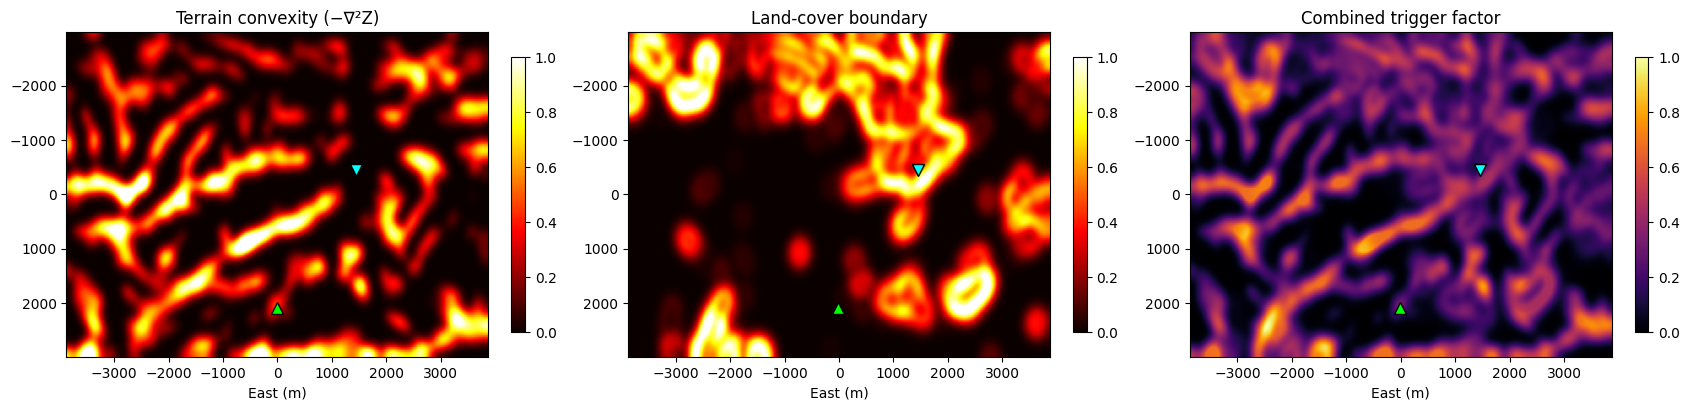

Saved data/trigger_factor.png


In [30]:
# ── Collector / Trigger factor ────────────────────────────────────────────────
# A "collector" is a broad area that absorbs solar energy and accumulates heat.
# A "trigger" is the specific terrain or boundary feature where that heat
# concentrates and releases as a thermal bubble.
#
# Two components are combined:
#   1. Terrain convexity  — NEGATIVE Laplacian (−∇²Z) identifies ridges, peaks,
#      and convex slope breaks.
#
#      Sign convention: ∇²Z = ∂²Z/∂x² + ∂²Z/∂y²
#        < 0  at local maxima (ridges, peaks) — surface curves downward → convex
#        > 0  at local minima (valleys, bowls) — surface curves upward  → concave
#      We keep only the negative part (−∇²Z > 0) to score convex features.
#
#   2. Land-cover boundary — gradient magnitude of thermal_factor identifies
#      abrupt surface transitions (forest/rock, clearing/forest, field/scrub)
#      which are classic trigger points.
#
# Both are normalised to [0, 1] and blended 60/40 (convexity dominates).
# The result is a static grid exported once; it does not change with time of day.

# ── 1. Terrain convexity ─────────────────────────────────────────────────────
# Smooth the DEM before taking second derivatives to suppress pixel-scale noise.
# sigma=4 px ≈ 100 m at the sim grid spacing — captures ridge-scale features.
Z_smooth    = gaussian_filter(Z_sim.astype(np.float64), sigma=4.0)
d2zdx2      = np.gradient(np.gradient(Z_smooth, axis=1), axis=1)
d2zdy2      = np.gradient(np.gradient(Z_smooth, axis=0), axis=0)
laplacian   = d2zdx2 + d2zdy2
# Ridges / peaks have NEGATIVE Laplacian → negate so they score positive
convexity   = np.maximum(-laplacian, 0.0)
convexity   = gaussian_filter(convexity, sigma=3.0)    # light smoothing
p99c        = np.percentile(convexity[convexity > 0], 99)
convexity_norm = np.clip(convexity / (p99c + 1e-9), 0, 1).astype(np.float32)

# ── 2. Land-cover boundary ────────────────────────────────────────────────────
# Gradient magnitude of thermal_factor — high where surfaces change abruptly.
dtf_dx      = np.gradient(thermal_factor_sim.astype(np.float64), axis=1)
dtf_dy      = np.gradient(thermal_factor_sim.astype(np.float64), axis=0)
boundary    = np.sqrt(dtf_dx**2 + dtf_dy**2).astype(np.float32)
boundary    = gaussian_filter(boundary, sigma=3.0)
p99b        = np.percentile(boundary[boundary > 0], 99)
boundary_norm = np.clip(boundary / (p99b + 1e-9), 0, 1).astype(np.float32)

# ── 3. Combined trigger factor ────────────────────────────────────────────────
trigger_factor_sim = (0.6 * convexity_norm + 0.4 * boundary_norm).astype(np.float32)
trigger_factor_sim /= (trigger_factor_sim.max() + 1e-9)   # normalise to [0, 1]

print('Trigger factor components:')
print(f'  Convexity  norm : mean={convexity_norm.mean():.3f}  '
      f'cells > 0.5: {(convexity_norm > 0.5).sum():,}')
print(f'  Boundary   norm : mean={boundary_norm.mean():.3f}  '
      f'cells > 0.5: {(boundary_norm > 0.5).sum():,}')
print(f'  Combined trigger: mean={trigger_factor_sim.mean():.3f}  '
      f'cells > 0.5: {(trigger_factor_sim > 0.5).sum():,}  '
      f'max={trigger_factor_sim.max():.3f}')

# Sanity: the highest trigger values should correspond to ridge lines
top_cells = np.argwhere(trigger_factor_sim > 0.8)
if len(top_cells):
    elev_at_top = Z_sim[top_cells[:, 0], top_cells[:, 1]]
    print(f'\n  Top trigger cells (score > 0.8): {len(top_cells):,}  '
          f'elevation range {elev_at_top.min():.0f}–{elev_at_top.max():.0f} m '
          f'(should be on ridges, not in valleys)')

# Quick sanity: plot
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
extent = [X.min(), X.max(), Y.max(), Y.min()]
for ax, data, title, cmap in [
    (axes[0], convexity_norm,     'Terrain convexity (−∇²Z)', 'hot'),
    (axes[1], boundary_norm,      'Land-cover boundary',       'hot'),
    (axes[2], trigger_factor_sim, 'Combined trigger factor',   'inferno'),
]:
    im = ax.imshow(data, cmap=cmap, origin='upper', extent=extent, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.03)
    ax.set_title(title)
    ax.set_xlabel('East (m)')
for wp, color, marker in [(LANDING, 'cyan', 'v'), (TAKEOFF, 'lime', '^')]:
    for ax in axes:
        ax.plot(wp['x'], wp['y'], marker=marker, color=color, ms=8, markeredgecolor='k')
plt.tight_layout()
plt.savefig('data/trigger_factor.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved data/trigger_factor.png')


In [31]:
import urllib.request
import json as _json
from datetime import datetime as _dt, timedelta as _td

def fetch_era5_dT_obs(lat, lon, date_str, window_days=7, years=None):
    """
    Query Open-Meteo ERA5 archive for clear-sky midday (surface_temperature - temperature_2m)
    around `date_str` ± window_days, across multiple years.

    Returns list of observed dT values (K).
    """
    target = _dt.strptime(date_str, '%Y-%m-%d')
    if years is None:
        current_year = _dt.now().year
        years = range(current_year - 5, current_year)   # last 5 complete years

    records = []
    for year in years:
        try:
            start = _dt(year, target.month, target.day) - _td(days=window_days)
            end   = _dt(year, target.month, target.day) + _td(days=window_days)
        except ValueError:
            continue   # e.g. Feb 29 in non-leap year
        # ERA5 on Open-Meteo lags ~5 days behind present
        end = min(end, _dt.now() - _td(days=6))
        if start >= end:
            continue

        url = (
            'https://archive.open-meteo.com/v1/archive'
            f'?latitude={lat:.4f}&longitude={lon:.4f}'
            f'&start_date={start.strftime("%Y-%m-%d")}'
            f'&end_date={end.strftime("%Y-%m-%d")}'
            '&hourly=temperature_2m,surface_temperature,direct_radiation'
            '&timezone=Europe%2FParis'
        )
        try:
            with urllib.request.urlopen(url, timeout=30) as resp:
                data = _json.loads(resp.read())
        except Exception as e:
            print(f'  Warning: year {year} fetch failed — {e}')
            continue

        h = data.get('hourly', {})
        times = h.get('time', [])
        t2m   = h.get('temperature_2m', [])
        tskin = h.get('surface_temperature', [])
        drad  = h.get('direct_radiation', [])

        for t, t2, ts, dr in zip(times, t2m, tskin, drad):
            if t2 is None or ts is None or dr is None:
                continue
            hour = int(t[11:13])
            if hour < 11 or hour > 14:   # local solar midday window
                continue
            if dr < 600:                  # clear-sky threshold (W/m²)
                continue
            records.append(ts - t2)

    return records


def calibrate_max_heat(lat, lon, date_str, scenarios,
                        Z_grid, thermal_factor_grid,
                        window_days=7, years=None):
    """
    Derive max_heat so the model's domain-averaged midday dT matches
    the ERA5-observed clear-sky surface–air temperature difference.

    Steps
    -----
    1. Fetch ERA5 clear-sky midday dT_obs for the date window.
    2. Run compute_solar_heating(max_heat=1) at noon over the actual
       simulation domain (includes real slope geometry + land cover)
       to get model_response per unit max_heat.
    3. max_heat = median(dT_obs) / mean(model_response)
    """
    print(f'Calibrating max_heat from ERA5 ({date_str} ±{window_days} days)…')
    dT_vals = fetch_era5_dT_obs(lat, lon, date_str, window_days, years)

    if not dT_vals:
        print('  WARNING: No ERA5 data returned — falling back to max_heat=15.0')
        return 15.0

    dT_obs = float(np.median(dT_vals))
    print(f'  ERA5 clear-sky midday dT: median={dT_obs:.2f} K  '
          f'(n={len(dT_vals)}, range={min(dT_vals):.1f}–{max(dT_vals):.1f} K)')

    # Noon scenario = highest sun elevation
    noon_sc = max(scenarios, key=lambda s: s['sun_elevation'])
    print(f'  Reference noon scenario: {noon_sc["local_time"]}  '
          f'az={noon_sc["sun_azimuth"]:.1f}°  el={noon_sc["sun_elevation"]:.1f}°')

    # Model response per unit max_heat over the actual simulation domain
    response_grid = compute_solar_heating(
        Z_grid,
        noon_sc['sun_azimuth'],
        noon_sc['sun_elevation'],
        thermal_factor=thermal_factor_grid,
        max_heat=1.0,
    )
    model_response = float(response_grid.mean())
    print(f'  Domain-mean model response (max_heat=1): {model_response:.4f}')

    max_heat = dT_obs / model_response
    print(f'  → max_heat = {dT_obs:.2f} / {model_response:.4f} = {max_heat:.2f} K')
    return max_heat


SCENARIOS = generate_sun_scenarios(
    BBOX['center_lat'], BBOX['center_lon'],
    date_str=SIMULATION_DATE,
    tz_offset_hours=TZ_OFFSET,
    interval_minutes=INTERVAL_MIN,
)

MAX_HEAT = calibrate_max_heat(
    BBOX['center_lat'], BBOX['center_lon'],
    SIMULATION_DATE,
    SCENARIOS,
    Z_sim, thermal_factor_sim,
)


Calibrating max_heat from ERA5 (2024-07-15 ±7 days)…


In [32]:
ARROW_STEP = 8   # downsample arrows: every N-th grid cell

# Arrow grid indices (same formula as JS so both sides agree)
arrow_js = list(range(ARROW_STEP // 2, SIM_NY, ARROW_STEP))
arrow_is = list(range(ARROW_STEP // 2, SIM_NX, ARROW_STEP))

DT_INTERVAL = INTERVAL_MIN / 60   # hours per scenario step

# ── Per-cell thermal inertia ──────────────────────────────────────────────────
TAU_FACTOR = {
    10:  2.50,   # Tree cover      — dense canopy slows response
    20:  1.30,   # Shrubland
    30:  1.00,   # Grassland       — reference
    40:  0.85,   # Cropland
    50:  0.50,   # Built-up        — concrete / asphalt
    60:  0.35,   # Bare / sparse   — rock and scree, heats and cools very fast
    70:  1.50,   # Snow and ice
    80: 15.00,   # Permanent water — enormous heat capacity
    90:  1.50,   # Herbaceous wetland
    95:  2.00,   # Mangrove
   100:  1.00,   # Moss and lichen
}

tau_grid   = np.vectorize(
    lambda c: TAU_FACTOR.get(int(c), 1.0)
)(lc_sim).astype(np.float32) * TAU_HOURS
decay_grid = np.exp(-DT_INTERVAL / tau_grid)

print(f'Thermal inertia: τ_ref={TAU_HOURS} h (grassland), dt={DT_INTERVAL} h')
print(f'  decay range: {decay_grid.min():.3f} (bare rock) – {decay_grid.max():.3f} (water)')
print(f'max_heat = {MAX_HEAT:.2f} K  (ERA5-calibrated)')
print(f'Terrain mesh (high-res): {MESH_NX} × {MESH_NY}')
print(f'Terrain sim  (30 m SRTM): {SIM_NX} × {SIM_NY}')

output = {
    'simulation_date': SIMULATION_DATE,
    'tz_offset':       TZ_OFFSET,
    'interval_min':    INTERVAL_MIN,
    'tau_hours':       TAU_HOURS,
    'max_heat':        MAX_HEAT,
    'terrain': {
        # ── Simulation grid (30 m SRTM) ─ used for all physics overlays ──────
        'nx': SIM_NX, 'ny': SIM_NY,
        'x_extent': [float(X_sim.min()), float(X_sim.max())],
        'y_extent': [float(Y_sim.min()), float(Y_sim.max())],
        'z_extent': [float(Z_min), float(Z_min + DOMAIN_H)],
        'dx': float(dx), 'dy': float(dy),
        'arrow_step': ARROW_STEP,
        'elevation': Z_sim.tolist(),
        'thermal_factor': thermal_factor_sim.tolist(),
        'trigger_factor': trigger_factor_sim.tolist(),
        'projection_origin': {'lat': LAT0, 'lon': LON0},
        # ── High-resolution mesh (AWS Terrarium ~7 m) ─ visual terrain only ──
        'mesh_nx':        MESH_NX,
        'mesh_ny':        MESH_NY,
        'mesh_dx':        float(mesh_dx),
        'mesh_dy':        float(mesh_dy),
        'mesh_elevation': Z_mesh.tolist(),
    },
    'markers': [
        {'name': LANDING['name'], 'type': 'landing',
         'x': LANDING['x'], 'y': LANDING['y'], 'z': LANDING['z']},
        {'name': TAKEOFF['name'], 'type': 'takeoff',
         'x': TAKEOFF['x'], 'y': TAKEOFF['y'], 'z': TAKEOFF['z']}
    ],
    'scenarios': []
}

dT_carry = np.zeros((SIM_NY, SIM_NX), dtype=np.float32)

for i, sc in enumerate(SCENARIOS):
    print(f"[{i+1:2d}/{len(SCENARIOS)}] {sc['local_time']}  "
          f"az={sc['sun_azimuth']:.1f}°  el={sc['sun_elevation']:.1f}°  "
          f"carry_max={dT_carry.max():.1f} K")

    shadow  = compute_shadow_mask(Z_sim, dx, dy, sc['sun_azimuth'], sc['sun_elevation'])
    dT_inst = compute_solar_heating(Z_sim, sc['sun_azimuth'], sc['sun_elevation'],
                                    thermal_factor=thermal_factor_sim,
                                    max_heat=MAX_HEAT,
                                    shadow_mask=shadow)

    dT_carry = dT_carry * decay_grid + dT_inst * (1.0 - decay_grid)

    u_flow, v_flow = compute_orographic_flow(Z_sim, dT_carry, dx, dy, smooth_sigma=5.0)

    u_ds = [[float(u_flow[j, ii]) for ii in arrow_is] for j in arrow_js]
    v_ds = [[float(v_flow[j, ii]) for ii in arrow_is] for j in arrow_js]

    output['scenarios'].append({
        'name':                sc['name'],
        'local_time':          sc['local_time'],
        'utc_time':            sc['utc_time'],
        'sun_azimuth':         sc['sun_azimuth'],
        'sun_elevation':       sc['sun_elevation'],
        'ground_temp_anomaly': dT_carry.tolist(),
        'shadow_mask':         shadow.flatten().astype(np.int8).tolist(),
        'u_surface':           u_ds,
        'v_surface':           v_ds,
    })

os.makedirs('data', exist_ok=True)
with open('data/simulation.json', 'w') as f:
    json.dump(output, f)

size_mb = os.path.getsize('data/simulation.json') / 1e6
n_arrows = len(arrow_js) * len(arrow_is)
print(f'\nSaved data/simulation.json  ({size_mb:.1f} MB) — {len(SCENARIOS)} scenarios, '
      f'{n_arrows} flow arrows per scenario')
print(f'Peak accumulated dT: {dT_carry.max():.1f} K')
print(f'Mesh elevation: {MESH_NX * MESH_NY:,} vertices at ~{mesh_dx:.0f} m resolution')


Thermal inertia: τ_ref=1.5 h (grassland), dt=1.0 h
  decay range: 0.264 (bare rock) – 0.766 (water)
max_heat = 15.00 K  (ERA5-calibrated)
Terrain mesh (high-res): 1229 × 694
Terrain sim  (30 m SRTM): 344 × 194
[ 1/15] 07:00  az=64.0°  el=4.0°  carry_max=0.0 K
[ 2/15] 08:00  az=73.6°  el=14.1°  carry_max=2.6 K
[ 3/15] 09:00  az=83.1°  el=24.8°  carry_max=5.0 K
[ 4/15] 10:00  az=93.1°  el=35.7°  carry_max=6.6 K
[ 5/15] 11:00  az=104.9°  el=46.5°  carry_max=7.5 K
[ 6/15] 12:00  az=120.5°  el=56.6°  carry_max=8.2 K
[ 7/15] 13:00  az=144.0°  el=64.8°  carry_max=8.3 K
[ 8/15] 14:00  az=178.5°  el=68.4°  carry_max=7.7 K
[ 9/15] 15:00  az=213.6°  el=65.3°  carry_max=7.5 K
[10/15] 16:00  az=237.9°  el=57.4°  carry_max=7.4 K
[11/15] 17:00  az=254.0°  el=47.3°  carry_max=7.2 K
[12/15] 18:00  az=265.9°  el=36.5°  carry_max=7.7 K
[13/15] 19:00  az=276.1°  el=25.6°  carry_max=8.0 K
[14/15] 20:00  az=285.6°  el=14.9°  carry_max=7.8 K
[15/15] 21:00  az=295.2°  el=4.7°  carry_max=7.0 K

Saved data/simu

## Phase 3 — Export for Three.js

Serve from project root: `python -m http.server 8000` → open `web/index.html`